<a href="https://colab.research.google.com/github/HieuStudyingCS/California-housing-price-prediction/blob/main/LinearRegression_California_Housing_pricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression from Scratch

## Gdown to download the dataset before running the model

If you do not have **gdown** on google colab, please copy all of the code in this code cell to install it

```
# Install gdown
!pip install gdown

# Download the file using File ID
import gdown
file_id = '1HWe3ZfQ6vUmQPh6zfnLtp2XC5T5PhI9A'
url = f'https://drive.google.com/file/d/1HWe3ZfQ6vUmQPh6zfnLtp2XC5T5PhI9A/view?usp=sharing'
gdown.download(url, 'MyDrive.csv', quiet=False)
```

In [ ]:
# Install gdown
!pip install gdown

# Download the file using File ID
import gdown
file_id = '1HWe3ZfQ6vUmQPh6zfnLtp2XC5T5PhI9A'
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, 'housing.csv', quiet=False)

In [4]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

## Loading data

In [2]:
# No need to run this code cell
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
housing = pd.read_csv('housing.csv')
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Data Preprocessing

In [ ]:
housing['total_bedrooms'] = housing['total_bedrooms'].fillna(housing['total_bedrooms'].median())

In [ ]:
housing = pd.get_dummies(housing, columns=['ocean_proximity'], drop_first=True)

In [ ]:
X = housing.drop(columns=['median_house_value']).values.astype(np.float64)
y = housing['median_house_value'].values.astype(np.float64).reshape(-1, 1)

In [ ]:
# Split datasets into 2 parts including training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Calculate mean and standard (Z-score Normalization)
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

In [ ]:
# Z-score Normalization
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

## Our model
In this project, I employ a linear regression model as:

\begin{equation}
f_w(x) = w_1x_1 + w_2x_2 +...+ w_nx_n + b
\end{equation}

with n is the number of columns in the datasets table

In [ ]:
class LinearRegressionScratch:
  def __init__(self, learning_rate=0.01, n_iterations=2000):
    self.lr = learning_rate
    self.n_iters = n_iterations
    self.weights = None
    self.bias = None
    self.loss_history = []

  def fit(self, X, y):
    n_samples, n_features = X.shape

    self.weights = np.zeros((n_features, 1))
    self.bias = 0

    for _ in range(self.n_iters):
      y_pred = np.dot(X, self.weights) + self.bias

      Loss = np.mean((y_pred - y) ** 2)
      self.loss_history.append(Loss)

      dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
      db = (2 / n_samples) * np.sum(y_pred - y)

      self.weights -= self.lr *dw
      self.bias -= self.lr * db

  def predict(self, X):
      return np.dot(X, self.weights) + self.bias

In [ ]:
model = LinearRegressionScratch(learning_rate=0.05, n_iterations=2000)
model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = model.predict(X_test_scaled)
print(f'MSE: {sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.4f}')

MSE: 70021.8745
R2 Score: 0.6258


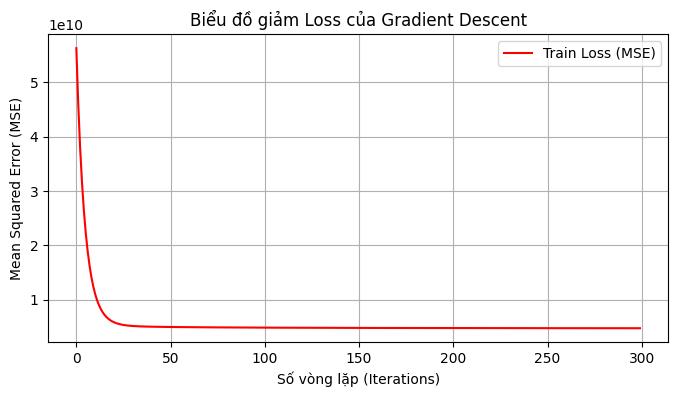

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history[:300], label="Train Loss (MSE)", color="red")
plt.title('Biểu đồ giảm Loss của Gradient Descent')
plt.xlabel('Số vòng lặp (Iterations)')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()